In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

df = pd.read_csv("preprocessed_data_1.csv")

In [65]:
df.columns

Index(['Employee_ID', 'Age', 'Experience_Years', 'Education', 'Department',
       'Job_Level', 'Performance_Rating', 'Projects_Completed',
       'Certifications', 'Weekly_Work_Hours', 'Remote_Work', 'City_Tier',
       'Job_Satisfaction', 'Salary_LPA', 'Salary_Status'],
      dtype='str')

Training Features: (2000, 20)
Testing Features: (500, 20)
Training Target: (2000,)
Testing Target: (500,)

Decision Tree Model Trained Successfully!

Decision Tree Model
-------------------
Median Salary: 2.1

Actual vs Predicted Salary Class
   Actual Salary Class  Predicted Salary Class
0                    1                       1
1                    0                       0
2                    0                       0
3                    1                       1
4                    0                       0
5                    1                       1
6                    1                       1
7                    0                       0
8                    1                       1
9                    0                       0


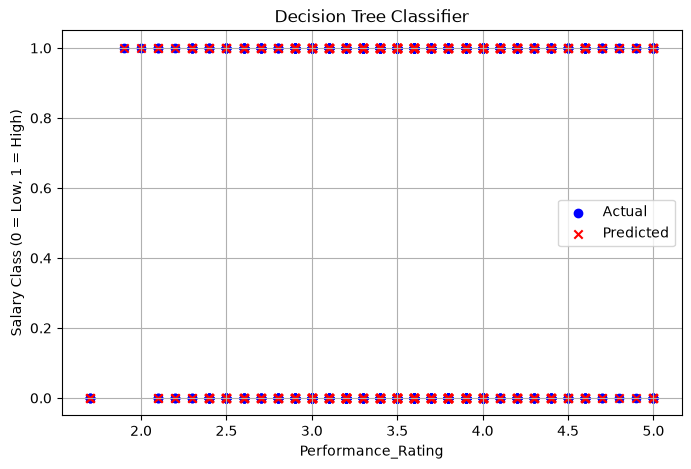

In [66]:

median_salary = df["Salary_LPA"].median()

df["Salary_Class"] = (
    df["Salary_LPA"] >= median_salary
).astype(int)
X = df[[
        "Age",
        "Experience_Years",
        "Education",
        "Department",
        "Job_Level",
        "Performance_Rating",
        "Projects_Completed",
        "Certifications",
        "Weekly_Work_Hours",
        "Remote_Work",
        "City_Tier",
        "Job_Satisfaction"
    ]]
y = df["Salary_Class"]
X = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)
model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=3,
    random_state=42
)
model.fit(X_train, y_train)

print("\nDecision Tree Model Trained Successfully!")
y_pred = model.predict(X_test)


print("\nDecision Tree Model")
print("-------------------")
print("Median Salary:", median_salary)
result = pd.DataFrame({
    "Actual Salary Class": y_test.values,
    "Predicted Salary Class": y_pred
})

print("\nActual vs Predicted Salary Class")
print(result.head(10))
plt.figure(figsize=(8, 5))
plt.scatter(
    X_test["Performance_Rating"],
    y_test,
    color="blue",
    label="Actual"
)
plt.scatter(
    X_test["Performance_Rating"],
    y_pred,
    color="red",
    marker="x",
    label="Predicted"
)
plt.title("Decision Tree Classifier")
plt.xlabel("Performance_Rating")
plt.ylabel("Salary Class (0 = Low, 1 = High)")
plt.legend()
plt.grid(True)



plt.show()

In [67]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

confusion_matrix = confusion_matrix(y_test,y_pred)
print("Confusion matrix: ",confusion_matrix)

classification_report = classification_report(y_test,y_pred)
print("Classification_report: ",classification_report)

f1_score = f1_score(y_test,y_pred)
print("f1_score: ",f1_score)

recall_score = recall_score(y_test,y_pred)
print("recall_score:",recall_score)

precision_score = precision_score(y_test,y_pred)
print("precision_score: ",precision_score)


Accuracy: 0.972
Confusion matrix:  [[246   4]
 [ 10 240]]
Classification_report:                precision    recall  f1-score   support

           0       0.96      0.98      0.97       250
           1       0.98      0.96      0.97       250

    accuracy                           0.97       500
   macro avg       0.97      0.97      0.97       500
weighted avg       0.97      0.97      0.97       500

f1_score:  0.97165991902834
recall_score: 0.96
precision_score:  0.9836065573770492


In [68]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)



mean_absolute_error = mean_absolute_error(y_test, y_pred)

mean_squared_error = mean_squared_error(y_test, y_pred)

rmse = mean_squared_error ** 0.5

r2 = r2_score(y_test, y_pred)
print("MAE :", mean_absolute_error)
print("MSE :", mean_squared_error)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 0.028
MSE : 0.028
RMSE: 0.1673320053068151
R2 Score: 0.888


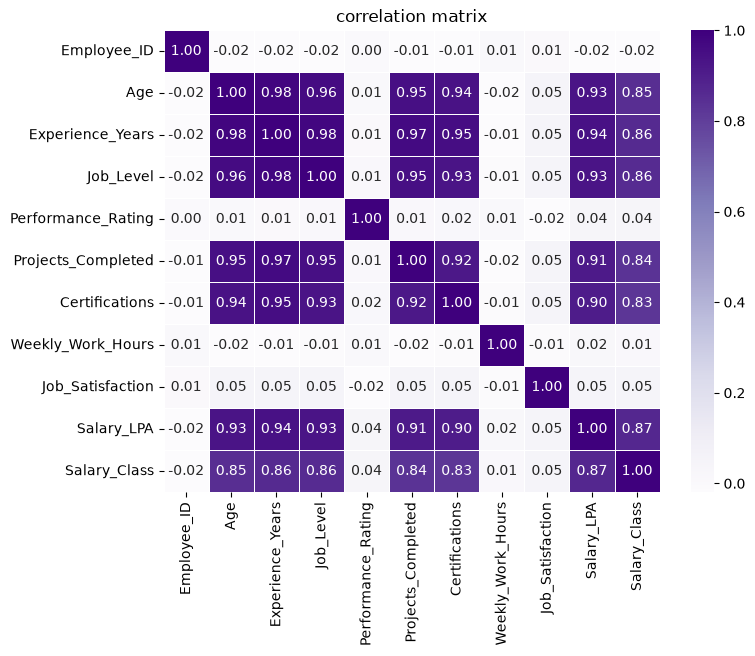

In [69]:
import  matplotlib.pyplot as plt
import seaborn as sns
corr_matrix=df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="Purples",
    fmt=".2f",
    linewidths=0.5
)
plt.title("correlation matrix")
plt.show()
